In [1]:
# Import all relevant libraries
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns


from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report,confusion_matrix,ConfusionMatrixDisplay,accuracy_score,f1_score
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV,KFold,RandomizedSearchCV

from category_encoders import OneHotEncoder

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

In [2]:
# Define Wrangle function
def wrangle(URL):
    df = pd.read_csv(URL)
    # Data preprocessing
    df['Date'] = pd.to_datetime(df['Date'])
    df['Day_of_month'] = df['Date'].dt.day
    df['Month'] = df['Date'].dt.month
    df['Is_weekend'] = df['Day_of_week'].isin(['Saturday', 'Sunday']).astype(int)


    df['Time'] = pd.to_datetime(df['Time'], format='%H:%M')
    df['hour'] = df['Time'].dt.hour
    df['Minute'] = df['Time'].dt.minute
    
    df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
    df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)



    # Drop columns that are not needed
    df.drop(columns= ['Time', 'hour','Date','State'], inplace=True)

    # Change the order of the "target" to ensure an ordinal progression and split
    order = {'Heavy': 4, 'High': 3, 'Normal': 2, 'Low': 1}
    df['Traffic_Situation'] = df['Traffic_Situation'].str.split("-").str[-1]
    df['Traffic_Situation'] = df['Traffic_Situation'].map(order)

    # Convert "bool" columns to integer
    bool_cols = df.select_dtypes(include='bool').columns
    df[bool_cols] = df[bool_cols].astype(int)

    # Drop leakages 
    df.drop(columns=["Total","Is_Raining"], inplace=True)
    
    return df
    

In [3]:
traffic_data = wrangle("lagos_synthetic_traffic_dataset.csv")
print(traffic_data.shape)
traffic_data.head()

(46080, 19)


,Day_of_week,Segment,Road_Type,Lanes,CarCount,KekeOkadaCount,BusCount,TruckCount,Is_Market_Day,Is_School_Hours,Rainfall_Intensity,Is_Fuel_Scarcity,Traffic_Situation,Day_of_month,Month,Is_weekend,Minute,hour_sin,hour_cos
0,Wednesday,Third Mainland Bridge,highway,6,32,27,14,5,0,0,0.0,0,1,1,1,0,0,0.0,1.0
1,Wednesday,Lekki-Epe Expressway,highway,6,27,21,12,5,0,0,0.0,0,1,1,1,0,0,0.0,1.0
2,Wednesday,Ikorodu Road,arterial,4,22,19,9,3,0,0,0.0,0,1,1,1,0,0,0.0,1.0
3,Wednesday,Agege Motor Road,arterial,3,15,12,6,3,0,0,0.0,0,1,1,1,0,0,0.0,1.0
4,Wednesday,Apapa-Oshodi Expressway,highway,6,32,28,13,4,0,0,0.0,0,1,1,1,0,0,0.0,1.0


In [4]:
traffic_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 46080 entries, 0 to 46079
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Day_of_week         46080 non-null  str    
 1   Segment             46080 non-null  str    
 2   Road_Type           46080 non-null  str    
 3   Lanes               46080 non-null  int64  
 4   CarCount            46080 non-null  int64  
 5   KekeOkadaCount      46080 non-null  int64  
 6   BusCount            46080 non-null  int64  
 7   TruckCount          46080 non-null  int64  
 8   Is_Market_Day       46080 non-null  int64  
 9   Is_School_Hours     46080 non-null  int64  
 10  Rainfall_Intensity  46080 non-null  float64
 11  Is_Fuel_Scarcity    46080 non-null  int64  
 12  Traffic_Situation   46080 non-null  int64  
 13  Day_of_month        46080 non-null  int32  
 14  Month               46080 non-null  int32  
 15  Is_weekend          46080 non-null  int64  
 16  Minute         

In [5]:
traffic_data.describe()

,Lanes,CarCount,KekeOkadaCount,BusCount,TruckCount,Is_Market_Day,Is_School_Hours,Rainfall_Intensity,Is_Fuel_Scarcity,Traffic_Situation,Day_of_month,Month,Is_weekend,Minute,hour_sin,hour_cos
count,46080.000000,46080.000000,46080.000000,46080.000000,46080.000000,46080.000000,46080.000000,46080.000000,46080.000000,46080.000000,46080.000000,46080.000000,46080.000000,46080.000000,4.608000e+04,4.608000e+04
mean,4.500000,110.502669,89.224023,47.538390,18.131228,0.283333,0.074653,0.002528,0.083333,1.684809,15.050000,1.500000,0.283333,22.500000,-9.868649e-18,-6.908054e-17
std,1.224758,86.116653,69.451446,37.455728,15.714727,0.450622,0.262833,0.043268,0.276388,0.796705,8.699568,0.532296,0.450622,16.770692,7.071145e-01,7.071145e-01
min,3.000000,3.000000,3.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,-1.000000e+00,-1.000000e+00
25%,3.750000,34.000000,28.000000,15.000000,5.000000,0.000000,0.000000,0.000000,0.000000,1.000000,7.750000,1.000000,0.000000,11.250000,-7.071068e-01,-7.071068e-01
50%,4.000000,96.000000,77.000000,41.000000,15.000000,0.000000,0.000000,0.000000,0.000000,2.000000,15.000000,1.000000,0.000000,22.500000,6.123234e-17,-6.123234e-17
75%,6.000000,164.000000,132.000000,70.000000,27.000000,1.000000,0.000000,0.000000,0.000000,2.000000,22.250000,2.000000,1.000000,33.750000,7.071068e-01,7.071068e-01
max,6.000000,526.000000,405.000000,228.000000,115.000000,1.000000,1.000000,0.800000,1.000000,4.000000,31.000000,3.000000,1.000000,45.000000,1.000000e+00,1.000000e+00


In [6]:
traffic_data.columns.to_list()

['Day_of_week',
 'Segment',
 'Road_Type',
 'Lanes',
 'CarCount',
 'KekeOkadaCount',
 'BusCount',
 'TruckCount',
 'Is_Market_Day',
 'Is_School_Hours',
 'Rainfall_Intensity',
 'Is_Fuel_Scarcity',
 'Traffic_Situation',
 'Day_of_month',
 'Month',
 'Is_weekend',
 'Minute',
 'hour_sin',
 'hour_cos']

In [7]:
# The percentage class distribution
(traffic_data['Traffic_Situation'].value_counts() / len(traffic_data['Traffic_Situation'])) * 100

Traffic_Situation
1    48.886719
2    37.322049
3    10.214844
4     3.576389
Name: count, dtype: float64

In [8]:
corr_matrix = traffic_data.select_dtypes("number").corr()
corr_matrix

,Lanes,CarCount,KekeOkadaCount,BusCount,TruckCount,Is_Market_Day,Is_School_Hours,Rainfall_Intensity,Is_Fuel_Scarcity,Traffic_Situation,Day_of_month,Month,Is_weekend,Minute,hour_sin,hour_cos
Lanes,1.000000e+00,0.405707,0.406710,0.401333,0.372213,5.495667e-16,-1.159565e-01,1.268737e-15,-4.553017e-15,0.153016,-4.050448e-15,-1.078247e-14,-1.933877e-15,-1.227262e-17,1.033008e-16,1.939266e-16
CarCount,4.057074e-01,1.000000,0.979406,0.978121,0.898409,9.063040e-02,1.845024e-01,2.048348e-02,-8.131914e-02,0.871210,2.919190e-02,-3.748789e-02,-1.110654e-01,9.947941e-04,-2.224405e-01,-5.883136e-01
KekeOkadaCount,4.067105e-01,0.979406,1.000000,0.973147,0.893692,1.008049e-01,1.861364e-01,9.882782e-03,4.544620e-02,0.874818,1.955696e-02,-1.875569e-04,-1.175767e-01,1.168660e-03,-2.232453e-01,-5.880279e-01
BusCount,4.013329e-01,0.978121,0.973147,1.000000,0.886844,9.407122e-02,1.836189e-01,3.437389e-02,-3.278951e-02,0.868133,2.585843e-02,-2.362844e-02,-1.134318e-01,9.040448e-04,-2.220204e-01,-5.846188e-01
TruckCount,3.722127e-01,0.898409,0.893692,0.886844,1.000000,9.159161e-02,1.708237e-01,1.815106e-02,-3.068340e-02,0.802620,2.381731e-02,-2.138173e-02,-1.041861e-01,1.576708e-03,-2.065024e-01,-5.408131e-01
Is_Market_Day,5.495667e-16,0.090630,0.100805,0.094071,0.091592,1.000000e+00,7.060595e-02,-1.785641e-02,7.806260e-02,0.127797,1.154299e-01,-3.474261e-02,-3.953488e-01,2.365968e-16,3.142351e-17,-4.260501e-17
Is_School_Hours,-1.159565e-01,0.184502,0.186136,0.183619,0.170824,7.060595e-02,1.000000e+00,-1.659384e-02,9.958085e-03,0.293322,2.949852e-02,-1.861421e-02,-1.785915e-01,1.129489e-16,6.274766e-02,-2.341775e-01
Rainfall_Intensity,1.268737e-15,0.020483,0.009883,0.034374,0.018151,-1.785641e-02,-1.659384e-02,1.000000e+00,-1.761489e-02,0.043038,-2.125370e-03,-5.487791e-02,-1.144520e-02,2.776180e-16,-6.593308e-02,-9.236577e-03
Is_Fuel_Scarcity,-4.553017e-15,-0.081319,0.045446,-0.032790,-0.030683,7.806260e-02,9.958085e-03,-1.761489e-02,1.000000e+00,0.005552,-7.105008e-02,2.832206e-01,-5.575900e-02,5.574940e-16,-3.673748e-17,-5.498352e-18
Traffic_Situation,1.530161e-01,0.871210,0.874818,0.868133,0.802620,1.277966e-01,2.933222e-01,4.303838e-02,5.551940e-03,1.000000,2.978083e-02,-1.647789e-02,-1.457338e-01,-6.578141e-04,-1.848821e-01,-5.391983e-01


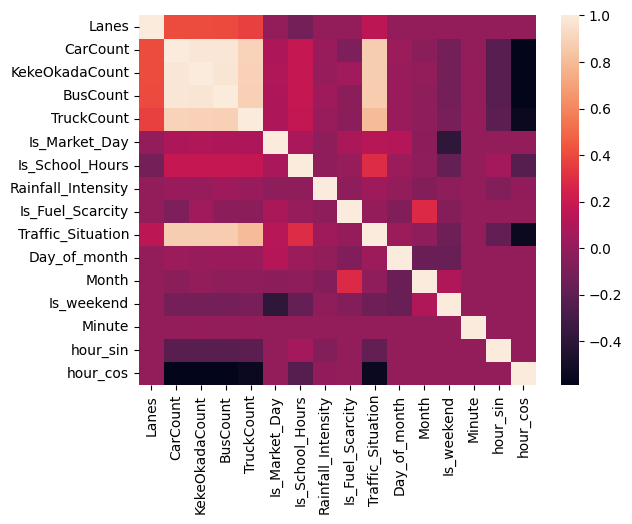

In [9]:
sns.heatmap(corr_matrix);

<!-- Check for class imbalance -->

# Check for class imbalance

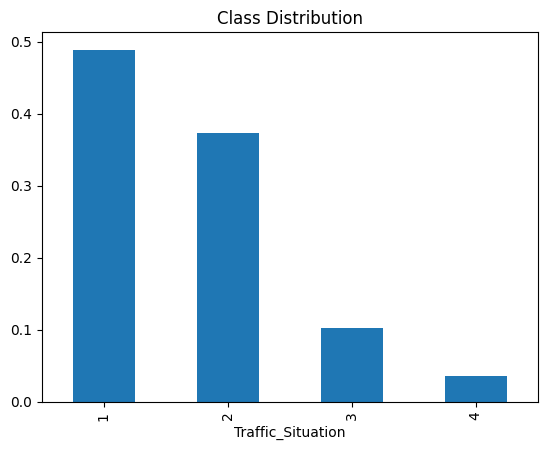

In [10]:
traffic_data['Traffic_Situation'].value_counts(normalize=True).plot(kind="bar")
plt.title("Class Distribution");

# Perform Data Split

In [11]:
X = traffic_data.drop(columns=['Traffic_Situation'])
y = traffic_data['Traffic_Situation']

print(X.shape)
print(y.shape)

(46080, 18)
(46080,)


In [12]:
X_train,X_test,y_train, y_test = train_test_split(
    X,y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape: ",X_train.shape)
print("X_test shape: ",X_test.shape)
print("y_train shape: ",y_train.shape)
print("y_test shape: ",y_test.shape)

X_train shape:  (36864, 18)
X_test shape:  (9216, 18)
y_train shape:  (36864,)
y_test shape:  (9216,)


# Baseline Model

We will build a simple DecisionTreeClassifier as our baseline model as a form of sanity check to how our ensemble model will perform

In [13]:
# clf = classifier
clf =make_pipeline(  
    OneHotEncoder(use_cat_names=True),
    DecisionTreeClassifier(random_state=42)
)
clf

Pipeline(steps=[('onehotencoder', OneHotEncoder(use_cat_names=True)),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(random_state=42))])

In [14]:
# Parameter Tuning
param_grid = {
    'decisiontreeclassifier__max_depth': [3, 5, 10, 20, None],
    'decisiontreeclassifier__min_samples_split': [2, 5, 10, 20],
    'decisiontreeclassifier__min_samples_leaf': [1, 2, 5, 10],
    'decisiontreeclassifier__criterion': ['gini', 'entropy']
}

grid_model = GridSearchCV(
    clf,
    param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

grid_model.fit(X_train, y_train)

print(grid_model.best_params_)
print(grid_model.best_score_)

Fitting 5 folds for each of 160 candidates, totalling 800 fits
{'decisiontreeclassifier__criterion': 'entropy', 'decisiontreeclassifier__max_depth': 20, 'decisiontreeclassifier__min_samples_leaf': 1, 'decisiontreeclassifier__min_samples_split': 5}
0.9409497864115544


In [15]:
# Tuned baseline model
tuned_model = grid_model.best_estimator_
tuned_model

Pipeline(steps=[('onehotencoder',
                 OneHotEncoder(cols=['Day_of_week', 'Segment', 'Road_Type'],
                               use_cat_names=True)),
                ('decisiontreeclassifier',
                 DecisionTreeClassifier(criterion='entropy', max_depth=20,
                                        min_samples_split=5,
                                        random_state=42))])

In [16]:
base_train_f1 = f1_score(y_train, tuned_model.predict(X_train), average='macro')
print("Baseline Training F1-macro:", base_train_f1)

Baseline Training F1-macro: 0.9941751395234438


In [17]:
# Test for leakage
y_pred = tuned_model.predict(X_test)
print(f"Test F1-macro: {f1_score(y_test, y_pred, average='macro')}")

Test F1-macro: 0.9500156101902018


# Note 

An test F1 - macro score slightly higher than cv is an indication that there are no leakages in our data, i.e the wrangle function we created earlier handled leakages and collinearity well

# The Real Model (Random Forest Classifier)

This is where our model is built, tested and deployed


In [18]:
clf_rf = make_pipeline(
    OneHotEncoder(use_cat_names=True),
    RandomForestClassifier(random_state=42,class_weight="balanced")
)
clf_rf

Pipeline(steps=[('onehotencoder', OneHotEncoder(use_cat_names=True)),
                ('randomforestclassifier',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])

In [19]:
# Hyperparameter tuning for rf model

param_grid_rf = {
    'randomforestclassifier__n_estimators': [100, 200, 300, 400, 500],
    'randomforestclassifier__max_depth': [None, 5, 10, 20],
    'randomforestclassifier__min_samples_split': [2, 5, 10],
    'randomforestclassifier__min_samples_leaf': [1, 2, 4]
}

kfold = KFold(n_splits=5, random_state=42, shuffle=True)


random_search_rf = RandomizedSearchCV(
    estimator=clf_rf,
    param_distributions=param_grid_rf,
    n_iter=10,               # Number of random combinations to try
    cv=kfold,
    scoring="f1_macro",   # Use accuracy or f1_macro for multiclass
    n_jobs=-1,
    verbose=2,
    random_state=42
)


random_result_rf = random_search_rf.fit(X_train, y_train)


print("Best score:", random_result_rf.best_score_)
print("Best parameters:", random_result_rf.best_params_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best score: 0.9479829887503485
Best parameters: {'randomforestclassifier__n_estimators': 500, 'randomforestclassifier__min_samples_split': 2, 'randomforestclassifier__min_samples_leaf': 2, 'randomforestclassifier__max_depth': None}


In [20]:
# Tuned model
model = random_result_rf.best_estimator_

In [21]:
print(f"Validation Accuracy: {model.score(X_test,y_test)} ")
print(f"Training Accuracy: {model.score(X_train,y_train)} ")
print(f"Overall Accuracy: {model.score(X,y)} ")

Validation Accuracy: 0.9713541666666666 
Training Accuracy: 0.9976942274305556 
Overall Accuracy: 0.9924262152777777 


In [22]:

y_pred = model.predict(X_test)
test_f1_macro = f1_score(y_test, y_pred, average='macro')
print("Test F1-macro:", round(test_f1_macro,3))

Test F1-macro: 0.947


In [23]:
train_f1_macro = f1_score(y_train, model.predict(X_train), average='macro')
print("Train F1-macro:", train_f1_macro)

Train F1-macro: 0.9959792747998666


In [24]:
full_f1_macro = f1_score(y, model.predict(X), average='macro')
print("Overall F1-macro (train+test combined):", full_f1_macro)

Overall F1-macro (train+test combined): 0.9860510155087447


In [25]:
print(f"{'Metric':<20}{'F1-macro':>10}")
print(f"{'CV (validation)':<20}{random_result_rf.best_score_:>10.3f}")
print(f"{'Train':<20}{train_f1_macro:>10.3f}")
print(f"{'Test':<20}{test_f1_macro:>10.3f}")

Metric                F1-macro
CV (validation)          0.948
Train                    0.996
Test                     0.947


In [26]:
# Classification report using the categorical value of the Target
print(classification_report(y_test,y_pred,target_names=['Low', 'Normal', 'High', 'Heavy']))

              precision    recall  f1-score   support

         Low       0.99      0.99      0.99      4505
      Normal       0.97      0.97      0.97      3440
        High       0.89      0.93      0.91       941
       Heavy       0.92      0.92      0.92       330

    accuracy                           0.97      9216
   macro avg       0.94      0.95      0.95      9216
weighted avg       0.97      0.97      0.97      9216



In [27]:
# Classification report using the Numerical value of the Target
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           1       0.99      0.99      0.99      4505
           2       0.97      0.97      0.97      3440
           3       0.89      0.93      0.91       941
           4       0.92      0.92      0.92       330

    accuracy                           0.97      9216
   macro avg       0.94      0.95      0.95      9216
weighted avg       0.97      0.97      0.97      9216



In [28]:
order = {1: 'Low', 2: 'Normal', 3: 'High', 4: 'Heavy'}
labels = [order[c] for c in model.classes_]

print(labels)

['Low', 'Normal', 'High', 'Heavy']


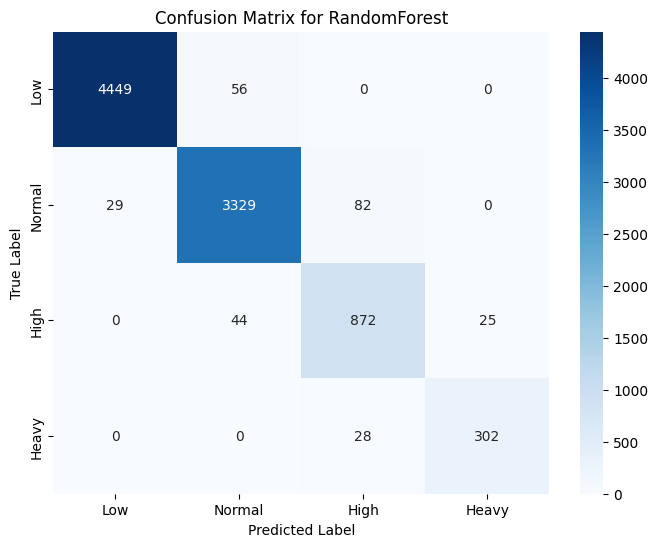

In [29]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix for RandomForest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Interpretation

The above confusion matrix provides insight as to how the model made it's prediction per class.
The diagonal values are the correct predictions of the model and all off-diagonal values are the mistakes or misclassified values of the model
# Class Breakdown
* Low: out of 4505 data points in this class, the model predicted 4449 correctly and misclassified 56 are Normal.
* Normal: out of 3440 values in this class, the model was able to predict 3329 correctly and misclassified 29 as Low and 82 as High.
* High: out of 941 data available in this class, the predicted correctly predicted 872 and misclassified 44 as Normal and 25 as Heavy.
* Heavy: out of 330 data in this class, the model predicted 302 as correct and misclassified 28 as High.

# Note:
The confusion matrix also proves or shows that the model had no issue predicting distant classes like low and heavy etc. This proves well for the users of this prediction as predicting Low as normal is a more acceptable mistake than predicting Low as Heavy or Vice versa.
* All the models mistakes were between close classes like low/normal, normal/high etc.


In [30]:
#  Extract feature importance from our model
features = model.named_steps["onehotencoder"].get_feature_names_out()
importance = model.named_steps["randomforestclassifier"].feature_importances_
features

array(['Day_of_week_Saturday', 'Day_of_week_Monday',
       'Day_of_week_Wednesday', 'Day_of_week_Sunday',
       'Day_of_week_Friday', 'Day_of_week_Tuesday',
       'Day_of_week_Thursday', 'Segment_Apapa-Oshodi Expressway',
       'Segment_Berger-Ojota Corridor', 'Segment_Ikorodu Road',
       'Segment_Third Mainland Bridge', 'Segment_Agege Motor Road',
       'Segment_Ajah-Sangotedo Road', 'Segment_Ozumba Mbadiwe',
       'Segment_Lekki-Epe Expressway', 'Road_Type_highway',
       'Road_Type_arterial', 'Lanes', 'CarCount', 'KekeOkadaCount',
       'BusCount', 'TruckCount', 'Is_Market_Day', 'Is_School_Hours',
       'Rainfall_Intensity', 'Is_Fuel_Scarcity', 'Day_of_month', 'Month',
       'Is_weekend', 'Minute', 'hour_sin', 'hour_cos'], dtype=object)

In [31]:
feat_importance = pd.Series(
     importance,
    index = features  
).sort_values()

feat_importance

Day_of_week_Monday                 0.001542
Day_of_week_Wednesday              0.001582
Day_of_week_Thursday               0.001722
Rainfall_Intensity                 0.001733
Day_of_week_Tuesday                0.002067
Day_of_week_Sunday                 0.002443
Day_of_week_Friday                 0.002492
Day_of_week_Saturday               0.002918
Segment_Apapa-Oshodi Expressway    0.003058
Month                              0.003170
Segment_Berger-Ojota Corridor      0.004089
Segment_Lekki-Epe Expressway       0.004907
Segment_Ajah-Sangotedo Road        0.005678
Minute                             0.005868
Segment_Agege Motor Road           0.006060
Is_Fuel_Scarcity                   0.006133
Segment_Third Mainland Bridge      0.006247
Segment_Ozumba Mbadiwe             0.006356
Is_Market_Day                      0.007316
Day_of_month                       0.011201
Is_weekend                         0.011316
Segment_Ikorodu Road               0.011715
Is_School_Hours                 

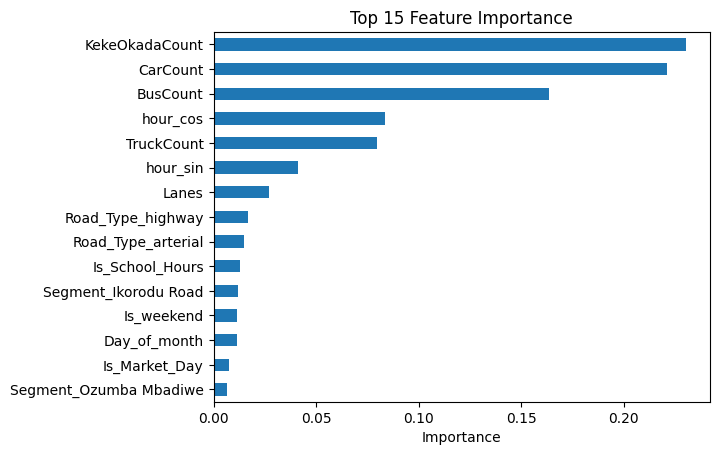

In [32]:
feat_importance.tail(15).plot(kind="barh")
plt.title("Top 15 Feature Importance")
plt.xlabel("Importance");

In [33]:
joblib.dump(model,"model.pkl")

['model.pkl']

# Final Note:

F1-macro was used as the performance metric for this model because unlike accuracy, it weights each class equally when computing the overall score. Although Accuracy was also used in this notebook it was used just to get a perception of what accuracy would have looked like on the model.
* Accuracy was not used as the primary metric because it weighs every prediction equally rather than every class equally and this is a problem considering that we have an imbalanced class